# Import packages needed for running code

In [9]:
import numpy as np
import itertools as it
from numpy.typing import NDArray
from scripts.environment import Environment

# Initiate environment

In [10]:
env = Environment(seed = 67)
env.sim_length = 1

# Define state space, probabilities, action space and reward space

In [11]:
def get_variables(env:Environment):
    """Initiate all variables.

    :param env: Class Environment. Contains the environment.
    :return: state space, number of states, number of actions
        reward matrix and policy matrix.
    """
    bsp_lvl = env.base_stock
    s = np.arange(bsp_lvl + 1)
    ss = np.array(list(it.product(s, repeat = env.M)))

    valid = ss.sum(axis=1) <= bsp_lvl
    ss = ss[valid]
    ns = len(ss)

    na = env.discount_levels

    rr = np.zeros([na, ns])
    pp = np.zeros([na, ns, ns])
    return ss, ns, na, rr, pp

In [12]:
ss, ns, na, rr, pp = get_variables(env)

# Check the number of states

In [13]:
def check_states(pp:NDArray, action_states:bool = False) -> None:
    """Check number of possible states under the constraints of the environment.

    :param pp: 3D array of shape (na,ns,ns), contains the probabilities of
        reaching the next state given current state s and current action.
    :param action_states: bool, indicates whether only the number of
        possible states should be printed, or also the number of possible
        states while performing an action. The latter is only valid if the
        probability matrix is filled.
    :return: None
    """

    print(f"Total number of states: {pp.shape[1]}")
    for i in range(pp.shape[0]):
        count = 0
        for j in range(pp.shape[1]):
            if pp[i, j, :].sum() == 1.0:
                count += 1
        if action_states:
            print(f'Action {i} has {count} possible states.')

In [14]:
# check number of possible states
check_states(pp, action_states = False)

Total number of states: 1287


# Compute reward and probability matrix
<ol>
  <li>Action: a discount on the oldest product.</li>
  <li>Reward: LEFO + FEFO - order costs</li>
  <li>State: combination of number of items per product age per day</li>
  <li>Probability: poisson model distribution around mu = 3</li>
</ol>





In [15]:
def get_matrices(env:Environment, ss:NDArray, pp:NDArray, rr:NDArray):
    """Create probability and reward matrices.

    :param env: Class environment. Contains the environment.
    :param ss: np.array of shape (ns,M). Contains all states.
    :param pp: np.array of shape (na,ns,ns). Contains probabilities for
        next state space given a current state and action.
    :param rr: np.array of shape (na,ns). Contains the rewards for each
        action space.
    :return: rewards matrix and probability matrix.
    """

    for ida, a in enumerate(range(env.discount_levels)): 
        env.reset()
        for ids, s in enumerate(ss):
            pp, tot_profit = env.get_probability_matrix(ss,pp,s,ida,ids,a)
            rr[ida, ids] = tot_profit
    return pp, rr

In [16]:
pp, rr = get_matrices(env,ss,pp,rr)

# Use Iterative Policy Evaluation with Policy Improvement.

In [17]:
def policy_iteration_and_evaluation(na:int, ns:int, ss:NDArray, rr:NDArray,
                                    pp:NDArray, verbose:bool = False):
    """Perform policy iteration and iterative policy evaluation.

    :param na: int. Number of possible actions.
    :param ns: int. Number of possible states.
    :param ss: np.array of shape (ns,ns). Contains all state spaces.
    :param rr: np.array of shape (na,ns). Contains the rewards for
        action spaces.
    :param pp: np.array of shape (na, ns, ns). Contains probabilities
        of the next state
        given the current action and state.
    :param verbose: bool. Whether to track model progress while running.
        Default = False.
    :return: best policy, np.array of shape (ns).
    """

    pi = np.random.choice(np.arange(na), size = ns)
    v= np.zeros(ns)
    gamma = 0.999
    policy_not_stable = True
    n_iter_pi = 0

    while policy_not_stable:
        v, n_iter_ipe = iterative_policy_evaluation(ss, pi, na, v,
                                                    rr, pp, gamma)
        policy_not_stable, pi = policy_improvement(pi,v,rr,pp,ns,na,ss)
        n_iter_pi += 1
        if verbose:
            print(f'n_iter_pi: {n_iter_pi}\tn_iter_ipe: {n_iter_ipe}')

    return pi

In [18]:
def iterative_policy_evaluation(ss:NDArray, pi:NDArray, na:int, v:NDArray,
                                 rr:NDArray, pp:NDArray, gamma:float = 0.9):
    """Perform iterative policy evaluation.

    :param ss: np.array of shape (ns,M). Contains all possible states.
    :param pi: np.array of shape (ns). Contains a policy.
    :param na: int. Number of possible actions.
    :param v: np.array of shape (ns). Contains the expected reward for
        any state.
    :param rr: np.array of shape (na,ns). Contains the rewards for
        action spaces.
    :param pp: np.array of shape (na, ns, ns). Contains probabilities of
        the next state given the current action and state.
    :param gamma: float. Discount in the Bellman equation. Default = 0.9.
    :return: Updated state value vector under the given policy and optionally
        the number of times the algorithm was run.
    """

    n_iter_ipe = 0
    theta = 0.0001 * (1 - gamma) / (2 * gamma)
    span = 1 + theta
    while span > theta:
        v_prev = v.copy()
        n_iter_ipe += 1
        for ids, s in enumerate(ss):
            a = pi[ids]
            ida = np.where(np.arange(na) == a)[0][0]
            v[ids] = rr[ida, ids] + gamma * pp[ida, ids, :] @ v_prev

        diff = v - v_prev
        span = max(diff) - min(diff)
        n_iter_ipe += 1
    return v, n_iter_ipe

In [19]:
def policy_improvement(pi:NDArray, v:NDArray, rr:NDArray, pp:NDArray,
                       ns:int, na:int, ss:NDArray, gamma:float = 0.9):
    """Perform policy improvement.

    :param pi: np.array of shape (ns). Contains a policy.
    :param v: np.array of shape (ns). Contains the expected state values
        for any state.
    :param rr: np.array of shape (na,ns). Contains the rewards for
        action spaces.
    :param pp: np.array of shape (na, ns, ns). Contains probabilities of
        the next state given the current action and state.
    :param ns: int. Number of states.
    :param na: int. Number of actions.
    :param ss: np.array of shape (ns, ns). Contains all states.
    :param gamma: float. Discount according to the Bellman equation.
        Default = 0.9.
    :return: bool, whether the best policy was found. np.array of shape (ns)
        that contains the best policy.
    """

    q = np.zeros([na, ns])

    pi_prev= pi.copy()
    policy_not_stable = False
    for ids, s in enumerate(ss):
        q_best = - np.inf
        for ida, a in enumerate(np.arange(na)):
            q[ida, ids] = rr[ida, ids] + gamma * pp[ida, ids, :] @ v
            if q[ida, ids] > q_best:
                pi[ids] = a
                q_best = q[ida, ids]
        if pi[ids] != pi_prev[ids]:
            policy_not_stable = True
    return policy_not_stable, pi

In [20]:
pi = policy_iteration_and_evaluation(na,ns,ss,rr,pp)

# Look into the contents of the final policy

In [21]:
def print_policy_contents(pi:NDArray) -> None:
    """Print the number of times an action is chosen in pi.

    :param pi: np.array of shape (ns). Contains the action to take
        for a given state.
    :return: None
    """
    val_d = {}
    for i in pi:
        if i in val_d:
            val_d[i] += 1
        else:
            val_d[i] = 1

    for key in sorted(val_d.keys()):
        print(f'Action {key} is chosen {val_d[key]} times')

In [22]:
print_policy_contents(pi)

Action 0 is chosen 546 times
Action 1 is chosen 61 times
Action 2 is chosen 131 times
Action 3 is chosen 186 times
Action 4 is chosen 168 times
Action 5 is chosen 105 times
Action 6 is chosen 67 times
Action 7 is chosen 17 times
Action 8 is chosen 6 times


# Run the policy on the model

In [23]:
def run_dp_model(env:Environment, pi:NDArray, ss:NDArray):
    """Run the best policy in the environment.

    :param env: Class environment. Contains the environment.
    :param pi: np.array of shape (ns). Contains a policy (the best).
    :param ss: np.array of shape (ns,ns). Contains the all states.
    :return: mean profit, waste and fill rate, all float.
    """

    done = False
    while not done:
        pi_a_idx = np.where((ss == env.inventory_matrix[env.t])
                            .all(axis = 1))[0][0].item()
        action = pi[pi_a_idx]
        _, _, done = env.step(action)

    profit = env.get_statistics()['profit']
    waste = env.get_statistics()['waste']
    fill_rate = env.get_statistics()['fill_rate']
    return profit, waste, fill_rate

In [24]:
env = Environment(seed = 67)
profit, waste, fill_rate = run_dp_model(env, pi, ss)
print(profit)
print(waste)
print(fill_rate)

175.82397260273973
0.05499630111715626
0.9192224661377445


# Value iteration

In [25]:
def value_iteration(na:int, ns:int, ss:NDArray, rr:NDArray, pp:NDArray,
                    gamma:float = 0.9, k:int = 50, theta:int = 1,
                    verbose = False):
    """Perform value iteration as dynamic programming.

    :param na: int. Number of actions.
    :param ns: int. Number of states.
    :param ss: np.array of shape (ns,ns). Contains all states.
    :param rr: np.array of shape (na,ns). Contains all rewards given a state
        action.
    :param pp: np.array of shape (na,ns,ns). Contains all probabilities for
        a next state given the current state and action.
    :param gamma: float. The discount value in the Bellman equation.
        Default = 0.9.
    :param k: int. maximum number value Iteration has to be performed.
        Default = 50.
    :param theta: int. Limits the model to perform value Iteration when
        the difference between new and old state value vectors is nihil.
            Default = 1.
    :param verbose: bool. Whether algorithm progress should be visible.
        Default = False.
    :return: best policy of type np.array with shape (ns)
    """

    pi = np.random.choice(np.arange(na), ns)  
    v= np.zeros(ns)
    theta = 0
    n_iter_vi = 0
    stop = False
    kk = 0

    while not stop:
        if verbose:
            print(f'n_iter_vi: {n_iter_vi}')
        kk += 1
        delta = 0

        for ids, s in enumerate(ss):
            vs = v[ids]
            v_best = -99999

            for ida, a in enumerate(np.arange(na)):
                v_try = rr[ida,ids] + gamma * pp[ida, ids, :] @ v
                if v_try > v_best:
                    v_best = v_try
                    pi[ids] = a
            v[ids] = v_best
            if delta < abs(v[ids] - vs):
                delta = abs(v[ids] - vs)
        if (kk == k) or (delta < theta):
            stop = True
        n_iter_vi += 1

    return pi

In [26]:
pi = value_iteration(na,ns,ss,rr,pp)
print_policy_contents(pi)

Action 0 is chosen 544 times
Action 1 is chosen 51 times
Action 2 is chosen 119 times
Action 3 is chosen 184 times
Action 4 is chosen 162 times
Action 5 is chosen 108 times
Action 6 is chosen 75 times
Action 7 is chosen 29 times
Action 8 is chosen 14 times
Action 9 is chosen 1 times


In [27]:
env = Environment(seed = 67)
profit, waste, fill_rate = run_dp_model(env, pi, ss)
print(profit)
print(waste)
print(fill_rate)

175.83253424657534
0.05453608730270246
0.919377317070949


# Baseline to compare model with



In [28]:
env = Environment(seed = 67)
profits = []
waste = []
for action in range(env.discount_levels):
    env.reset()
    done = False
    while not done:
        _, _, done = env.step(action)
    profits.append(env.get_statistics()['profit'])
    waste.append(env.get_statistics()['waste'])

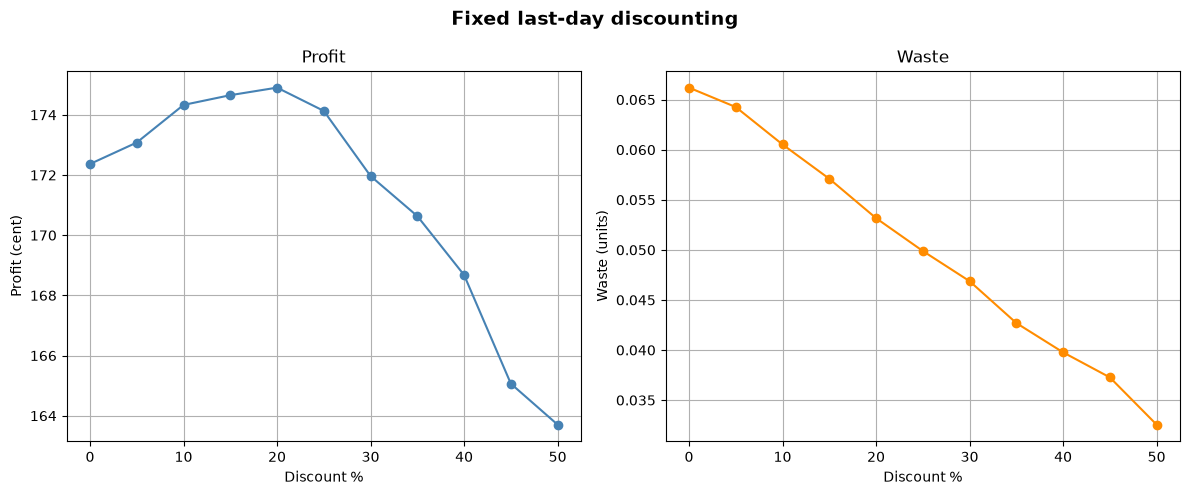

In [29]:
env.plot_env_results(profits, waste)

In [34]:
with open('../data/fdc_profit_waste.csv', 'w') as f:
    f.write('profit,waste\n')
    for i in range(len(profits)):
        f.write(f'{profits[i]},{waste[i]}\n')

# Functions to evaluate model

In [27]:
def run_ipe_and_pi(env:Environment):
    """Run Iterative Policy Evaluation and Policy Improvement.

    :param env: Class Environment. Contains the environment.
    :return: policy, profit, waste, fill rate
    """

    temp = env.sim_length
    env.sim_length = 1

    print('=====PROGRESS IPE+PI=====')
    print('0%')
    ss, ns, na, rr, pp = get_variables(env)
    print('20%')
    pp, rr = get_matrices(env,ss,pp,rr)
    print('50%')
    pi = policy_iteration_and_evaluation(na,ns,ss,rr,pp)
    print('70%')
    env.sim_length = temp
    env.reset()
    profit, waste, fill_rate = run_dp_model(env, pi, ss)
    print('100')
    print('=====END IPE+PI=====\n')
    return pi, profit, waste, fill_rate

In [28]:
env = Environment()
print(run_ipe_and_pi(env))

=====PROGRESS IPE+PI=====
0%
20%
50%
70%
100
=====END IPE+PI=====

(array([0, 0, 0, ..., 0, 0, 0], shape=(1287,)), np.float64(174.35239726027396), np.float64(0.05554617750769), np.float64(0.9188503649635037))


In [29]:
def run_vi(env:Environment):
    """Run value Iteration.

    :param env: Class Environment. Contains the environment.
    :return: policy, profit, waste, fill rate
    """

    temp = env.sim_length
    env.sim_length = 1

    print('=====PROGRESS VI=====')
    print('0%')
    ss, ns, na, rr, pp = get_variables(env)
    print('20%')
    pp, rr = get_matrices(env,ss,pp,rr)
    print('40%')
    pi = value_iteration(na,ns,ss,rr,pp)
    print('70%')
    env.sim_length = temp
    env.reset()
    profit, waste, fill_rate = run_dp_model(env, pi, ss)
    print('100%')
    print('=====END VI=====\n')
    return pi, profit, waste, fill_rate

In [30]:
env = Environment()
print(run_vi(env))

=====PROGRESS VI=====
0%
20%
40%
70%
100%
=====END VI=====

(array([0, 0, 0, ..., 0, 0, 0], shape=(1287,)), np.float64(174.38698630136986), np.float64(0.0548894892866524), np.float64(0.9191788321167883))
